# Analysing data from Tobias's diagnostic
The cell below loads the data, drops unnecessary variables and only keeps a selected time range (displayed on `phi2` trace).

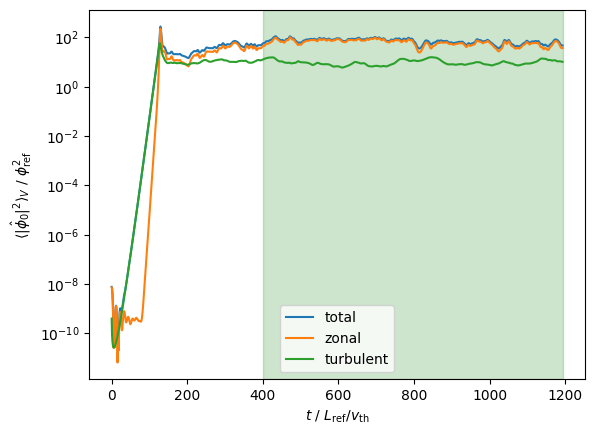

In [6]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm

filename = "../cbc-electrostatic-kappa1p5/kappa1p5.out.nc"

# Open dataset, but only load required_vars for performance
ds = xr.open_dataset(filename, engine="netcdf4")
required_vars = ["phi_t", "phi2", "phi2_by_mode", "entropy_transfer_3D", "kx", "ky", "t"]
vars_to_delete = []
for var in ds.data_vars:
    if var not in required_vars:
        vars_to_delete.append(var)
ds = ds.drop_vars(vars_to_delete)

# Plot phi2 over time to determine rough saturation region
kx_range = 2 * ds["kx"].max() # positive and negative
t = ds["t"]
t_sat = t.sel(t=400, method="nearest").values    # saturated by t=400ish
t_end = t[-1]
T = t_end - t_sat   # time domain over which to integrate

phi2_total = ds["phi2"]
phi2_zonal = ds["phi2_by_mode"].sel(ky=0).sum(dim="kx")
phi2_turb = phi2_total - phi2_zonal

plt.plot(t, phi2_total, label="total")
plt.plot(t, phi2_zonal, label="zonal")
plt.plot(t, phi2_turb, label="turbulent")
plt.xlabel(r"$t$" + " / " + r"$L_\mathrm{ref}/v_\mathrm{th}$")
plt.ylabel(r"$\langle|\hat{\phi}_0|^2\rangle_V$" + " / " + 
                  r"$\phi_\mathrm{ref}^2$")
plt.yscale("log")

# Highlight saturated region on the plot
plt.axvspan(t_sat, t_end, color="green", alpha=0.2)
plt.legend()
plt.show()

# Only keep data from the saturated region
drop_indices = ds['t'].where((ds['t'] < t_sat) | (ds['t'] > t_end), drop=True).values
ds = ds.drop_sel(t=drop_indices)

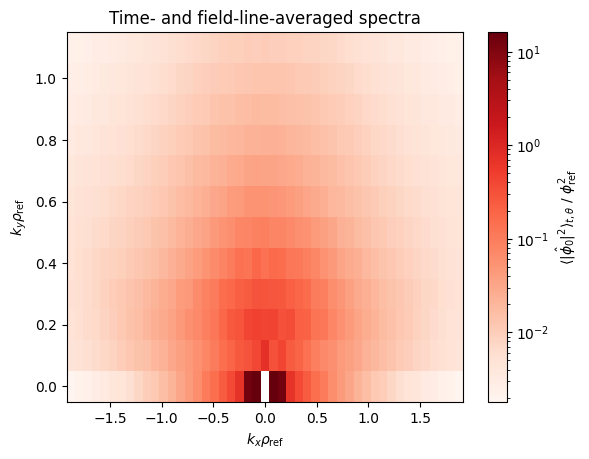

In [7]:
def get_boundaries(centres):
    """Given 1D array of N cell centres, returns an array of (N+1) cell boundaries
    """

    # First check if input array is uniformly spaced
    diffs = np.diff(centres)
    if not np.allclose(diffs, diffs[0]):
        raise ValueError(f"Input array is not uniformly spaced. Differences: {diffs}")
    edges = np.zeros(centres.size + 1)
    edges[1:-1] = (centres[:-1] + centres[1:]) / 2.0
    edges[0] = centres[0] - (centres[1] - centres[0]) / 2.0
    edges[-1] = centres[-1] + (centres[-1] - centres[-2]) / 2.0

    return edges

# 'roll' and 'sort' to change structure of kx 
# from [0.0, 0.08, ..., 1.89, -1.89, ..., -0.08] 
# to [-1.89, ..., -0.08, 0.0, 0.08, ..., 1.89]
ds = ds.roll(kx=len(ds["kx"] // 2), roll_coords=True)
ds = ds.sortby("kx")

integrated_phi2_by_mode = (1 / T) * ds["phi2_by_mode"].integrate(coord="t")
kx_edges = get_boundaries(ds["kx"].values)
ky_edges = get_boundaries(ds["ky"].values)

plt.pcolormesh(kx_edges, ky_edges, integrated_phi2_by_mode, 
               cmap="Reds", shading="auto", norm=LogNorm())
plt.colorbar(label=r"$\langle|\hat{\phi}_0|^2\rangle_{t,\theta}$" + 
            " / " + r"$\phi_\mathrm{ref}^2$")
plt.xlabel(r"$k_x\rho_\mathrm{ref}$")
plt.ylabel(r"$k_y\rho_\mathrm{ref}$")
plt.title("Time- and field-line-averaged spectra")
plt.show()



Load the 3D transfer data and integrate over time (quite slow; takes around 2 mins on my laptop).

In [8]:
entropy_transfer = ds["entropy_transfer_3D"]    # T(kys, kxs, kxt, theta, t)
transfer_over_time = (1 / (2 * np.pi)) * entropy_transfer.integrate(coord="theta") # T(kys, kxs, kxt, t)
transfer_structure = (1 / T) * entropy_transfer.integrate(coord="t") # T(kys, kxs, kxt, theta)
integrated_transfer = (1 / T) * transfer_over_time.integrate(coord="t") # T(kys, kxs, kxt)

This block plots the transfer for the selected `ky` source mode. 

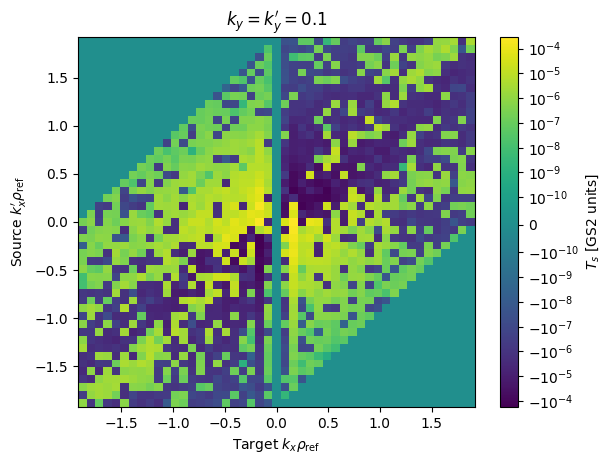

In [9]:
def plot_transfer_over_kx(transfer, iky_offset, filename=None):
    # iky0 = len(transfer["kys"]) // 2
    # ikyt = iky0 + iky_offset
    ikyt = iky_offset
    ikys = ikyt     # zonal transfer

    kxt, kxs = np.meshgrid(transfer["kxt"], transfer["kxs"])

    selected_transfer = transfer.isel(kys=ikys).values
    
    norm = SymLogNorm(linthresh=1e-10)

    plt.pcolormesh(kxt, kxs, selected_transfer, shading="auto", norm=norm)
    plt.colorbar(label=r"$T_s$" + " [GS2 units]")
    plt.xlabel("Target " + r"$k_x\rho_\mathrm{ref}$")
    plt.ylabel("Source " + r"$k_x'\rho_\mathrm{ref}$")
    plt.title(r"$k_y=k_y'=$" + str(transfer["kys"][ikys].values))

    if filename is not None:
        plt.savefig(filename)
    plt.show()

# iky_offset indexes the target ky and source ky'
# here ky = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1]
plot_transfer_over_kx(transfer=integrated_transfer, iky_offset=1)


Plot transfer over time

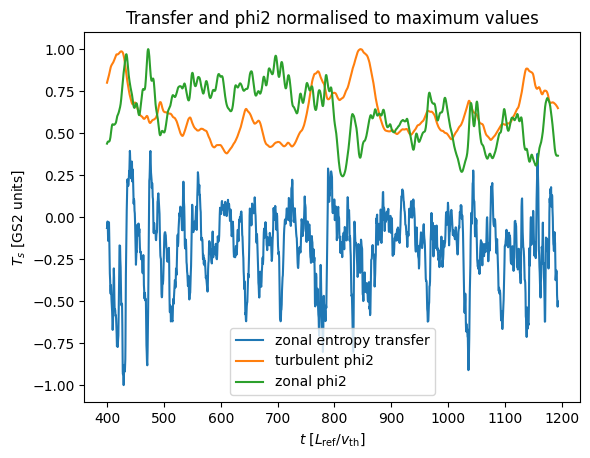

In [10]:
def plot_transfer_over_time(transfer, phi2_turb, phi2_zonal, filename=None):
    t = transfer["t"]

    # normalise values
    transfer_normalised = transfer / abs(transfer).max()
    phi2_turb_normalised = phi2_turb / abs(phi2_turb).max()
    phi2_zonal_normalised = phi2_zonal / abs(phi2_zonal).max()

    plt.plot(t, transfer_normalised, label="zonal entropy transfer")
    plt.plot(t, phi2_turb_normalised, label="turbulent phi2")
    plt.plot(t, phi2_zonal_normalised, label="zonal phi2")
    plt.xlabel(r"$t$" + " " + r"$[L_\mathrm{ref}/v_\mathrm{th}]$")
    plt.ylabel(r"$T_s$" + " [GS2 units]")
    plt.title("Transfer and phi2 normalised to maximum values")

    if filename is not None:
        plt.savefig(filename)
    plt.legend()
    plt.show()

# reload phi2_zonal and phi2_turb now that pre-saturated region has been dropped
phi2_total = ds["phi2"]
phi2_zonal = ds["phi2_by_mode"].sel(ky=0).sum(dim="kx")
phi2_turb = phi2_total - phi2_zonal

# plot transfer, phi2_turb and phi2_zonal over time
total_transfer_over_time = transfer_over_time.sum(dim=["kys", "kxs", "kxt"])
plot_transfer_over_time(total_transfer_over_time, phi2_turb, phi2_zonal)

Plot poloidal structure of the transfer

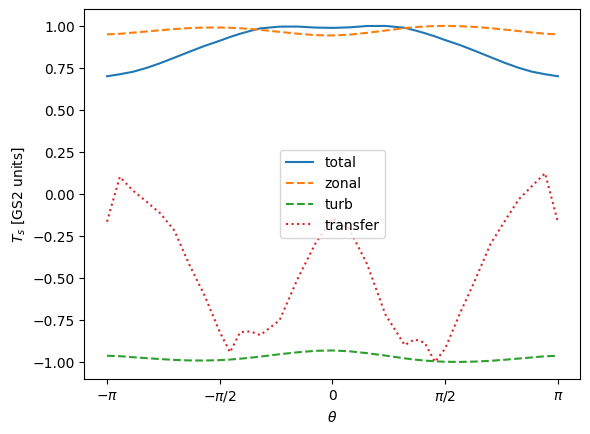

In [16]:
def normalise(array):
    return array / np.abs(array).max()


def plot_structure(transfer, phi2_total_by_theta, phi2_zonal_by_theta, phi2_turb_by_theta, filename=None):
    theta = transfer["theta"]

    plt.plot(theta, normalise(phi2_total_by_theta.values), label="total")
    plt.plot(theta, normalise(phi2_zonal_by_theta.values), label="zonal", linestyle="dashed")
    plt.plot(theta, normalise(phi2_turb_by_theta.values), label="turb", linestyle="dashed")
    plt.plot(theta, normalise(transfer.values), label="transfer", linestyle="dotted")
    plt.xlabel(r"$\theta$")
    plt.xticks(np.linspace(-np.pi, np.pi, 5), 
            [r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])
    plt.ylabel(r"$T_s$" + " [GS2 units]")
    plt.legend()
    plt.show()


# get phi_t as a function of theta
kx_range = 2 * ds["kx"].max()
ky_range = ds["ky"].max()

phi2_by_mode_by_theta = (ds["phi_t"].sel(ri=0)**2 + ds["phi_t"].sel(ri=1)**2).integrate(coord="t")

phi2_total_by_theta = ( 1 / (kx_range * ky_range) ) * phi2_by_mode_by_theta.integrate(coord=["kx", "ky"])
phi2_zonal_by_theta = (1 / kx_range) * phi2_by_mode_by_theta.sel(ky=0).integrate(coord="kx")
phi2_turb_by_theta = phi2_total_by_theta - phi2_zonal_by_theta

poloidal_structure = transfer_structure.sum(dim=["kys", "kxs", "kxt"])
plot_structure(poloidal_structure, phi2_total_by_theta, phi2_zonal_by_theta, phi2_turb_by_theta)